# Prediction du Nutri-Score — Random Forest + Cross-Validation

| Fichier | Role |
|---|---|
| `produits_avec_nutriscore.csv` | Donnees d'**entrainement** (produits FR avec grade etabli + toutes features presentes) |
| `produits_sans_nutriscore.csv` | Produits a **predire** (grade inconnu) |

## Pipeline
1. Chargement des deux datasets
2. Entrainement Random Forest
3. **Cross-Validation** (Stratified K-Fold, k=5)
4. Evaluation finale (rapport, matrice de confusion, importance)
5. Prediction sur les produits sans Nutri-Score
6. Sauvegarde CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Chargement des deux datasets

In [2]:
# --- Colonnes nutritionnelles = features du modele ---
FEATURES = [
    'energy_100g',
    'sugars_100g',
    'saturated-fat_100g',
    'salt_100g',
    'fiber_100g',
    'proteins_100g',
    'fruits-vegetables-legumes_100g',
]
TARGET = 'nutriscore_grade'
GRADES_VALIDES = ['a', 'b', 'c', 'd', 'e']

def charger(path):
    import os
    for p in [path, '../' + path, 'Nutri/' + path]:
        if os.path.exists(p):
            return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Introuvable : {path}")

# --- Dataset d'entrainement ---
df_train = charger('produits_avec_nutriscore.csv')
df_train[TARGET] = df_train[TARGET].str.lower().str.strip()
df_train = df_train[df_train[TARGET].isin(GRADES_VALIDES)]

# --- Dataset de prediction ---
df_pred = charger('produits_sans_nutriscore.csv')

print(f"Entrainement  : {len(df_train):,} produits")
print(f"A predire     : {len(df_pred):,} produits")
print(f"\nDistribution des grades (entrainement) :")
print(df_train[TARGET].value_counts())

Entrainement  : 106,067 produits
A predire     : 33,216 produits

Distribution des grades (entrainement) :
nutriscore_grade
d    25544
c    25344
e    25228
a    18018
b    11933
Name: count, dtype: int64


In [3]:
features_dispo = [f for f in FEATURES if f in df_train.columns]
print(f"Features utilisees ({len(features_dispo)}) : {features_dispo}")

X = df_train[features_dispo]
y = df_train[TARGET]

# Hold-out final 20 % pour la matrice de confusion
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain : {len(X_train):,}  |  Test (hold-out) : {len(X_test):,}")

Features utilisees (7) : ['energy_100g', 'sugars_100g', 'saturated-fat_100g', 'salt_100g', 'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g']

Train : 84,853  |  Test (hold-out) : 21,214


## 2. Pipeline sklearn

- **Imputation** : mediane (robuste aux valeurs aberrantes)  
- **Modele** : `RandomForestClassifier` 200 arbres, classes equilibrees

In [4]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

## 3. Cross-Validation Stratifiee (k = 5)

La **StratifiedKFold** garantit que chaque fold respecte la distribution des grades.
On mesure l'accuracy et le F1-macro sur les 5 folds.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1
)

df_cv = pd.DataFrame({
    'Fold'           : range(1, 6),
    'Train Accuracy' : cv_results['train_accuracy'].round(4),
    'Val Accuracy'   : cv_results['test_accuracy'].round(4),
    'Val F1-macro'   : cv_results['test_f1_macro'].round(4),
})

print(df_cv.to_string(index=False))
print(f"\nMoyenne Val Accuracy : {df_cv['Val Accuracy'].mean():.4f} +/- {df_cv['Val Accuracy'].std():.4f}")
print(f"Moyenne Val F1-macro : {df_cv['Val F1-macro'].mean():.4f} +/- {df_cv['Val F1-macro'].std():.4f}")

 Fold  Train Accuracy  Val Accuracy  Val F1-macro
    1          0.9564        0.9090        0.8985
    2          0.9572        0.9108        0.9007
    3          0.9571        0.9062        0.8960
    4          0.9566        0.9064        0.8973
    5          0.9564        0.9036        0.8929

Moyenne Val Accuracy : 0.9072 +/- 0.0028
Moyenne Val F1-macro : 0.8971 +/- 0.0029


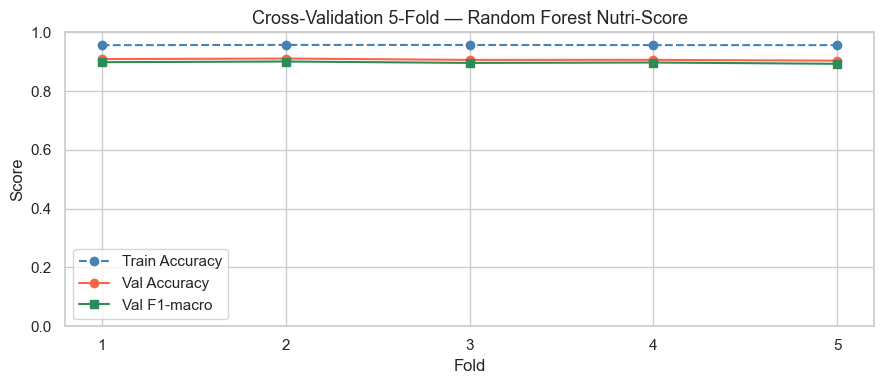

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(1, 6)
ax.plot(x, cv_results['train_accuracy'], 'o--', label='Train Accuracy', color='steelblue')
ax.plot(x, cv_results['test_accuracy'],  'o-',  label='Val Accuracy',   color='tomato')
ax.plot(x, cv_results['test_f1_macro'],  's-',  label='Val F1-macro',   color='seagreen')
ax.set_xticks(list(x))
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Cross-Validation 5-Fold — Random Forest Nutri-Score', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 3b. Learning Curve

La **learning curve** montre comment les scores train et validation evoluent selon la taille du jeu d'entrainement.  
Un ecart important entre les deux courbes signale un **sur-apprentissage** (overfitting) ; des courbes proches et basses signalent un **sous-apprentissage** (underfitting).

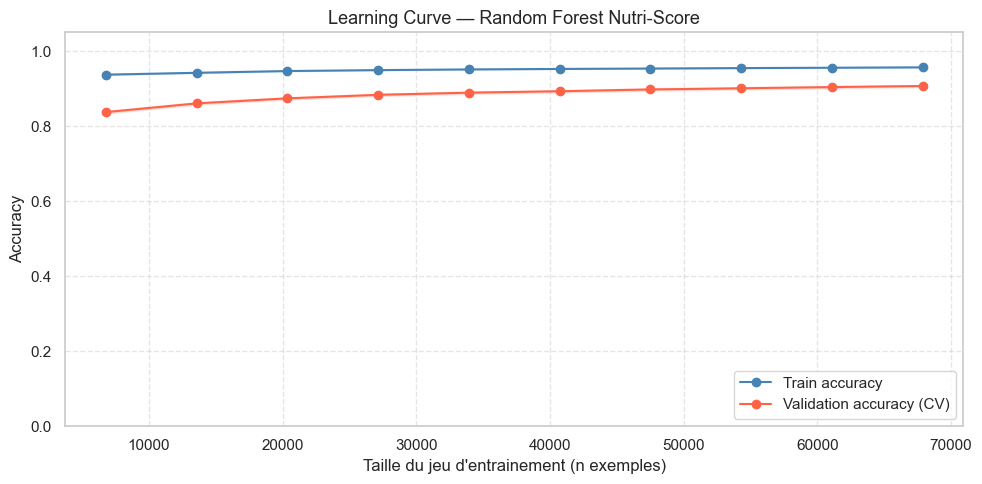

In [7]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')

ax.plot(train_sizes, val_mean, 'o-', color='tomato', label='Validation accuracy (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tomato')

ax.set_xlabel("Taille du jeu d'entrainement (n exemples)")
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Learning Curve — Random Forest Nutri-Score', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3c. OOB Error — equivalent de la fonction de perte

Le Random Forest n'optimise pas de gradient loss au sens classique.  
Son equivalent est l'erreur **Out-of-Bag (OOB)** : pour chaque arbre, les exemples non tires au sort  
servent de validation interne. En tracant l'**OOB error** en fonction du nombre d'arbres,  
on observe la convergence du modele — analogue a une courbe de loss.

C:\Users\Gambey\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
C:\Users\Gambey\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\Gambey\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differ

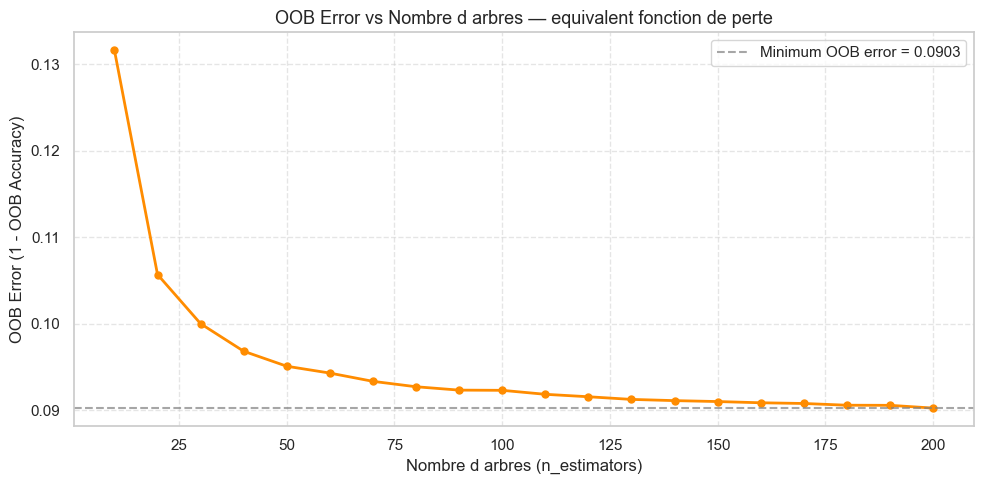

Meilleur n_estimators selon OOB : 200  (OOB error = 0.0903)


In [8]:
from sklearn.impute import SimpleImputer
import numpy as np

# Imputer separe pour alimenter le RF avec oob_score
imputer_oob = SimpleImputer(strategy='median')
X_imp = imputer_oob.fit_transform(X_train)

MAX_TREES = 200
oob_errors = []

rf_oob = RandomForestClassifier(
    n_estimators=MAX_TREES,
    warm_start=True,
    oob_score=True,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

for n in range(10, MAX_TREES + 1, 10):
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_imp, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

n_trees_range = list(range(10, MAX_TREES + 1, 10))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_trees_range, oob_errors, 'o-', color='darkorange', linewidth=2, markersize=5)
ax.axhline(min(oob_errors), linestyle='--', color='grey', alpha=0.7,
           label=f'Minimum OOB error = {min(oob_errors):.4f}')
ax.set_xlabel('Nombre d arbres (n_estimators)')
ax.set_ylabel('OOB Error (1 - OOB Accuracy)')
ax.set_title('OOB Error vs Nombre d arbres — equivalent fonction de perte', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_n = n_trees_range[oob_errors.index(min(oob_errors))]
print(f"Meilleur n_estimators selon OOB : {best_n}  (OOB error = {min(oob_errors):.4f})")

## 4. Entrainement final et evaluation sur le hold-out

On entraine le pipeline sur **tout** le jeu d'entrainement (sans les 20 % hold-out)  
puis on evalue sur les 20 % reserves.

In [9]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy hold-out : {acc:.4f} ({acc*100:.1f} %)\n")
print(classification_report(y_test, y_pred, target_names=[g.upper() for g in sorted(y_test.unique())]))

Accuracy hold-out : 0.9145 (91.5 %)

              precision    recall  f1-score   support

           A       0.91      0.92      0.92      3604
           B       0.78      0.86      0.82      2386
           C       0.92      0.88      0.90      5069
           D       0.93      0.93      0.93      5109
           E       0.97      0.95      0.96      5046

    accuracy                           0.91     21214
   macro avg       0.90      0.91      0.90     21214
weighted avg       0.92      0.91      0.92     21214



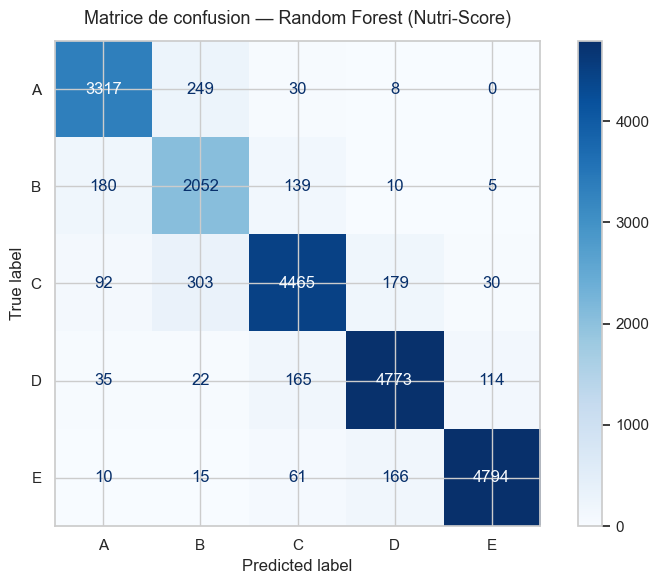

In [10]:
labels_ordre = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_ordre)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=[g.upper() for g in labels_ordre]).plot(ax=ax, cmap='Blues')
ax.set_title('Matrice de confusion — Random Forest (Nutri-Score)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [11]:
# % d'erreur sur le dataset ou nous avons deja le nutriscore (hold-out)
erreur_hold_out = 1 - acc
print(f"Erreur hold-out : {erreur_hold_out:.4f} ({erreur_hold_out*100:.1f} %)")


Erreur hold-out : 0.0855 (8.5 %)


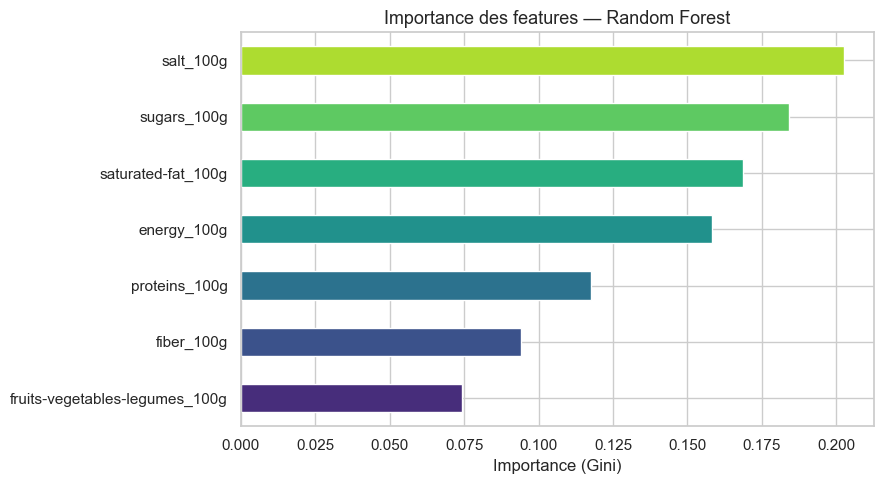

In [12]:
importances = pd.Series(pipeline.named_steps['rf'].feature_importances_, index=features_dispo).sort_values()

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color=sns.color_palette('viridis', len(importances)))
plt.title('Importance des features — Random Forest', fontsize=13)
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

## 5. Prediction sur les produits sans Nutri-Score

On re-entraine le pipeline sur **100 %** des donnees labellisees avant de predire.

In [13]:
# Entrainement sur 100 % du dataset labelise
pipeline.fit(X, y)

X_pred = df_pred[[f for f in features_dispo if f in df_pred.columns]]

predictions = pipeline.predict(X_pred)
probas      = pipeline.predict_proba(X_pred).max(axis=1)

df_pred = df_pred.copy()
df_pred['nutriscore_grade_predit'] = predictions
df_pred['confiance_modele']        = probas.round(3)

print(f"{len(df_pred):,} produits ont recu une prediction.\n")
print("Distribution des grades predits :")
print(df_pred['nutriscore_grade_predit'].value_counts())

cols_apercu = ['product_name', 'energy_100g', 'sugars_100g', 'saturated-fat_100g',
               'salt_100g', 'proteins_100g', 'fiber_100g',
               'nutriscore_grade_predit', 'confiance_modele']
cols_apercu = [c for c in cols_apercu if c in df_pred.columns]
display(df_pred[cols_apercu].head(10))

33,216 produits ont recu une prediction.

Distribution des grades predits :
nutriscore_grade_predit
e    9239
d    7210
c    6303
b    5287
a    5177
Name: count, dtype: int64


,product_name,energy_100g,sugars_100g,saturated-fat_100g,salt_100g,proteins_100g,fiber_100g,nutriscore_grade_predit,confiance_modele
0,Beijing Jjajang Ramen,1814.814815,3.703704,5.185185,2.296296,8.888889,1.481481,e,0.850
1,Huile de coco extra vierge,3700.000000,6.220000,94.600000,0.000000,0.000000,9.000000,b,0.327
2,Multi Grain,505.112500,20.512821,0.000000,0.961538,7.692308,7.692308,c,0.389
3,Hummus Traditional,1000.083333,0.371428,1.670000,0.832500,6.670000,6.670000,a,0.460
4,Paradizniki suseni lidl,581.000000,17.000000,0.200000,6.600000,7.000000,6.000000,e,0.494
5,Kakao,1603.000000,0.300000,13.200000,0.100000,22.300000,30.800000,d,0.424
6,Raw fruit &amp; nut bar,1547.000000,49.000000,1.700000,0.020000,6.600000,9.500000,d,0.880
7,THE ORIGINAL REFRIGERATED PROTEIN BAR,2207.692308,27.692308,6.153846,0.262500,23.076923,6.153846,d,0.820
8,Lait écrémé en poudre,1525.600000,52.000000,0.500000,1.082500,36.000000,0.000000,e,0.679
9,Simply Granola,1832.000000,13.800000,4.300000,0.012106,9.900000,7.200000,c,0.815


## 6. Sauvegarde des resultats

In [14]:
fichier_sortie = 'predictions_nutriscore_rf.csv'
df_pred.to_csv(fichier_sortie, index=False, encoding='utf-8')
print(f"Fichier sauvegarde : {fichier_sortie}")
print(f"  {len(df_pred):,} lignes  |  {len(df_pred.columns)} colonnes")

Fichier sauvegarde : predictions_nutriscore_rf.csv
  33,216 lignes  |  132 colonnes
